# ontoProc2 -- leveraging semantic SQL for ontology analysis in Bioconductor

**Author:** Vincent J. Carey, stvjc at channing.harvard.edu

# Introduction

The ontoProc2 package has two aims:

- to give convenient access to the ontologies that are transformed to "semantic SQL" in the [INCAtools semantic SQL project](https://github.com/INCATools/semantic-sql);
- to simplify operations that have been available in [ontoProc](https://git.bioconductor.org/packages/ontoProc), which will be deprecated in 2027.

This package is a "second generation" approach to ontology management and processing for Bioconductor. The ontoProc package was introduced in 2018 and had a number of experimental approaches to interface design and content caching. This package streamlines the identification and management of diverse ontologies by specifically leveraging semantic SQL concepts.

Specifically, the call `ontoProc::getOnto('cellOnto')` would produce an `ontologyIndex` instance. To work with Cell Ontology with ontoProc2, use `semsql_connect(ontology="cl")`. The abbreviated notation for ontologies follows that of the Open Biological and Biomedical Ontologies ([OBO](https://github.com/OBOFoundry/)) Foundry.

# Installation

Prior to the release of Bioconductor 3.24, use `BiocManager::install("vjcitn/ontoProc2")`.

For Bioconductor 3.24 and subsequent versions, use `BiocManager::install("ontoProc2")`.

# Acquiring ontologies

## Make a connection

The best way to work with an ontology in this system is to use `semsql_connect`. The `ontology` argument will be a short string that the INCAtools project uses as part of the filename for the ontology. For Gene Ontology, the string is "go".

In [1]:
library(ontoProc2)
goss <- semsql_connect(ontology = "go")
goss

1/27 packages newly attached/loaded, see sessionInfo() for details.

Connected to SemanticSQL database: /Users/vincentcarey/Library/Caches/org.R-project.R/R/BiocFileCache/40e293b372b_go.db

Primary ontology prefix: GO



<SemsqlConn>  prefix: GO  | labeled terms: 88,356 

## Make a report

The `report` method provides details.

In [2]:
report(goss)


SemsqlConn Object

Connection Details:
---------------------------------------- 
  Database path:    /Users/vincentcarey/Library/Caches/org.R-project.R/R/BiocFileCache/40e293b372b_go.db 
  Ontology prefix:  GO 
  Status:           ✓   Connected 

Database Statistics:
---------------------------------------- 
  Labeled terms:    88,356 
  Direct edges:     214,146 
  Entailed edges:   9,336,957 
  Definitions:      55,200 

Terms by Prefix (top 5):
---------------------------------------- 
  GO:              48,251
  CHEBI:           23,969
  _:               7,497
  UBERON:          4,783
  CL:              1,307

Key Tables Available:
---------------------------------------- 
  ✓  rdfs_label_statement 
  ✓  has_text_definition_statement 
  ✓  edge 
  ✓  entailed_edge 
  ✓  rdfs_subclass_of_statement 
  ✓  owl_some_values_from 
  ✓  has_oio_synonym_statement 

Use methods like search_labels(), get_ancestors(), etc.
Run ?SemsqlConn for documentation.



## Probe the back end

The back end is SQLite. We can enumerate the tables available:

In [3]:
library(dplyr)
library(DBI)
allt <- dbListTables(goss@con)
length(allt)
head(allt)

1/0 packages newly attached/loaded, see sessionInfo() for details.

1/0 packages newly attached/loaded, see sessionInfo() for details.



[1] 100

[1] "all_problems"                    "annotation_property_node"       
[3] "anonymous_class_expression"      "anonymous_expression"           
[5] "anonymous_individual_expression" "anonymous_property_expression"

## Use tidy methods

Individual tables are readily accessible.

In [4]:
library(DT)
tbl(goss@con, "statements")
tbl(goss@con, "statements") |>
  head(20) |>
  as.data.frame() |>
  datatable()

1/1 packages newly attached/loaded, see sessionInfo() for details.



# A query:  ?? x 8
# Database: sqlite 3.53.3 [/Users/vincentcarey/Library/Caches/org.R-project.R/R/BiocFileCache/40e293b372b_go.db]
   stanza                 subject predicate object value datatype language graph
   <chr>                  <chr>   <chr>     <chr>  <chr> <chr>    <chr>    <chr>
 1 obo:go/extensions/go-… obo:go… owl:vers… NA     2026… NA       NA       NA   
 2 obo:go/extensions/go-… obo:go… oio:hasO… NA     1.2   NA       NA       NA   
 3 obo:go/extensions/go-… obo:go… oio:defa… NA     gene… NA       NA       NA   
 4 obo:go/extensions/go-… obo:go… dcterms:… cc:by… NA    NA       NA       NA   
 5 obo:go/extensions/go-… obo:go… dce:title NA     Gene… NA       NA       NA   
 6 obo:go/extensions/go-… obo:go… dce:desc… NA     The … NA       NA       NA   
 7 obo:go/extensions/go-… obo:go… IAO:0000… GO:00… NA    NA       NA       NA   
 8 obo:go/extensions/go-… obo:go… IAO:0000… GO:00… NA    NA       NA       NA   
 9 obo:go/extensions/go-… obo:go… IAO:0000… GO:00… NA    N

HTML widgets cannot be represented in plain text (need html)

To investigate the ontology, searching through RDF labels is a natural approach.

In [5]:
search_labels(goss, "apoptosis") |>
  head() |>
  datatable()

HTML widgets cannot be represented in plain text (need html)

Additional filtering could be useful here to focus on GO terms. The `_riog...` labels have special roles in RDF inference, and this will be addressed in vignettes to be added in the future.

Let's improve the query:

In [6]:
search_labels(goss, "apoptosis") |>
  filter(grepl("^GO:", subject)) |>
  head() |>
  datatable()

HTML widgets cannot be represented in plain text (need html)

Clearly it will be valuable to filter away obsolete terms. We will investigate the use of edge tables to accomplish this in a future vignette.

# Transformation to ontology_index instances

The [ontologyX suite](https://academic.oup.com/bioinformatics/article/33/7/1104/2843897) of Daniel Greene and colleagues provides very convenient ontology handling functions. We can transform the SQLite data to this format. We'll illustrate with cell ontology.

In [7]:
clss <- semsql_connect(ontology = "cl")
cloi <- semsql_to_oi(clss@con)
cloi

Connected to SemanticSQL database: /Users/vincentcarey/Library/Caches/org.R-project.R/R/BiocFileCache/235e3797d178_cl.db

Primary ontology prefix: CL

Warning message in ontologyIndex::ontology_index(name = nn, parents = pl):
"Some parent terms not found: BFO:0000002, BFO:0000004, SO:0000704 (15 more)"


Ontology with 18603 terms

Properties:
	id: character
	name: list
	parents: list
	children: list
	ancestors: list
	obsolete: logical
Roots:
	UBERON:0000105 - life cycle stage
	GO:0008150 - biological_process
	GO:0003674 - molecular_function
	UBERON:0000465 - material anatomical entity
	UBERON:0000466 - immaterial anatomical entity
	GO:0005575 - cellular_component
	PATO:0000001 - quality
	PR:000010543 - myeloperoxidase
	IAO:0000027 - data entity
	PR:000001338 - complement receptor type 2
 ... 876 more

A convenience function assists with visualizations:

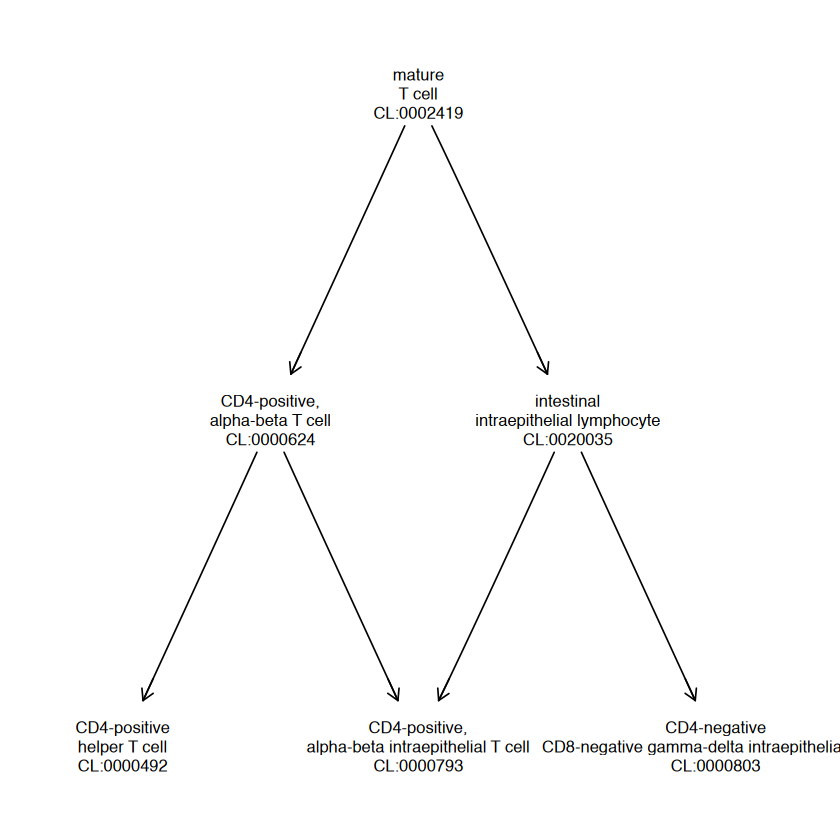

In [8]:
onto_plot2(cloi, c("CL:0000624", "CL:0000492", "CL:0000793", "CL:0000803"))

# Background

The S7 class design in this package was initiated by a request to Anthropic Claude to use S7 in establishing code that mirrors the tasks accomplished in the [INCAtools jupyter notebook](https://github.com/INCATools/semantic-sql/blob/main/notebooks/SemanticSQL-Tutorial.ipynb).

## Searching in label text

The code of `search_labels` is:

In [23]:
library(S7)
print(S7::method(search_labels, SemsqlConn))

0/0 packages newly attached/loaded, see sessionInfo() for details.



<S7_method> method(search_labels, ontoProc2::SemsqlConn)
function (x, pattern, limit = 20L) 
{
    dbGetQuery(x@con, "SELECT subject, value AS label FROM rdfs_label_statement\n      WHERE value LIKE ? LIMIT ?", 
        param = list(paste0("%", pattern, "%"), as.integer(limit)))
}
<environment: namespace:ontoProc2>


## Exploring concept properties with 'edge tables'

The INCAtools notebook discusses the fact that `rdfs_label_statement` is a SQLite table "view".

The notebook indicates that a SPARQL query on an RDF store for the following computation would be "quite hard". We want to find all the "edges" leading from "enteric neuron", which would constitute the set of subject-predicate-object statements about this cell type with "enteric neuron" as subject.

In this code we use the concept of a "CURIE" (Compact Uniform Resource Identifier): a fixed length numerical identifier with a prefix indicating the source ontology in which the ontologic concept is based.

In [10]:
if (!is_connected(clss)) clss <- reconnect(clss)
entcurie <- search_labels(clss, "enteric neuron") |>
  filter(grepl("^CL", subject)) |>
  dplyr::select(subject) |>
  unlist()
entcurie
get_direct_edges(clss, entcurie)

subject 
"CL:0007011"

subject,subject_label,predicate,predicate_label,object,object_label
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
CL:0007011,enteric neuron,BFO:0000050,part of,UBERON:0002005,enteric nervous system
CL:0007011,enteric neuron,BFO:0000050,part of,UBERON:0002005,enteric nervous system
CL:0007011,enteric neuron,RO:0002100,has soma location,UBERON:0002005,enteric nervous system
CL:0007011,enteric neuron,RO:0002100,has soma location,UBERON:0002005,enteric nervous system
CL:0007011,enteric neuron,RO:0002202,develops from,CL:0002607,migratory enteric neural crest cell
CL:0007011,enteric neuron,rdfs:subClassOf,NA,CL:0000029,neural crest derived neuron
CL:0007011,enteric neuron,rdfs:subClassOf,NA,CL:0000107,autonomic neuron


Here the underlying code is performing a join:

In [21]:
print(S7::method(get_direct_edges, SemsqlConn))

<S7_method> method(get_direct_edges, ontoProc2::SemsqlConn)
function (x, term_id, direction = c("outgoing", "incoming", "both")) 
{
    direction = match.arg(direction)
    query.init <- "SELECT\n      e.subject,\n      sl.value AS subject_label,\n      e.predicate,\n      pl.value AS predicate_label,\n      e.object,\n      ol.value AS object_label\n    FROM edge e\n    LEFT JOIN rdfs_label_statement sl ON e.subject = sl.subject\n    LEFT JOIN rdfs_label_statement pl ON e.predicate = pl.subject\n    LEFT JOIN rdfs_label_statement ol ON e.object = ol.subject\n    WHERE"
    if (direction == "outgoing") {
        query.fin <- "e.subject = ?"
        query = paste(query.init, query.fin)
        return(dbGetQuery(x@con, query, param = list(term_id)))
    }
    else if (direction == "incoming") {
        query.fin <- "e.object = ?"
        query = paste(query.init, query.fin)
        return(dbGetQuery(x@con, query, param = list(term_id)))
    }
    else if (direction == "both") {
        q

## Generalizing a concept: Ancestors

The notebook mentions that the "entailed edges" table includes all statements that can be inferred from the application of base axioms of the ontology.

In [12]:
get_ancestors(clss, entcurie)

,id,label,predicate
,<chr>,<chr>,<chr>
1,BFO:0000002,NA,rdfs:subClassOf
2,BFO:0000004,NA,rdfs:subClassOf
3,BFO:0000040,NA,rdfs:subClassOf
4,UBERON:0001062,anatomical entity,rdfs:subClassOf
5,UBERON:0000061,anatomical structure,rdfs:subClassOf
6,CL:0000107,autonomic neuron,rdfs:subClassOf
7,CL:0000000,cell,rdfs:subClassOf
8,CL:0000211,electrically active cell,rdfs:subClassOf
9,CL:0000393,electrically responsive cell,rdfs:subClassOf


## Working with multiple ontologies

The INCAtools notebook includes an example of finding all neurons that are part of the forebrain. This involves identifying CURIEs for relations and anatomical structures, thus working with the relational ontology (RO) and UBERON.

In [13]:
ub <- semsql_connect(ontology = "uberon")
ro <- semsql_connect(ontology = "ro")

Connected to SemanticSQL database: /Users/vincentcarey/Library/Caches/org.R-project.R/R/BiocFileCache/40e22de1c3cc_uberon.db

Primary ontology prefix: UBERON

Connected to SemanticSQL database: /Users/vincentcarey/Library/Caches/org.R-project.R/R/BiocFileCache/53b7a3ff554_ro.db

Primary ontology prefix: RO



First question: What's the CURIE for "forebrain" in UBERON?

In [14]:
fbcur <- search_labels(ub, "forebrain", limit = 1000) |>
  filter(label == "forebrain") |>
  select(subject) |>
  unlist()
fbcur

subject 
"UBERON:0001890"

Second question: What's the CURIE for "has soma location" in RO?

In [15]:
loccur <- search_labels(ro, "has soma location") |>
  select(subject) |>
  unlist()
loccur

subject 
"RO:0002100"

What's the CURIE for "neuron"?

In [16]:
ncur <- search_labels(clss, "neuron", limit = 1000) |>
  filter(label == "neuron") |>
  select(subject) |>
  unlist()
ncur

subject 
"CL:0000540"

Now we use three steps to obtain the solution.

First, enumerate all cell types that are located in forebrain.

In [17]:
clinfb <- tbl(clss@con, "entailed_edge") |>
  filter(predicate == loccur, object == fbcur) |>
  select(subject) |>
  collect() |>
  unlist()
length(clinfb)

[1] 186

Second, filter these to those identified as 'subclassOf' "neuron".

In [18]:
clisneur <- tbl(clss@con, "entailed_edge") |>
  filter(predicate == "rdfs:subClassOf", object == ncur) |>
  filter(subject %in% clinfb) |>
  select(subject) |>
  collect() |>
  unlist()
length(clisneur)

[1] 186

Finally, get the labels.

In [19]:
tbl(clss@con, "rdfs_label_statement") |>
  filter(subject %in% clisneur) |>
  select(subject, value) |>
  collect() |>
  DT::datatable()

HTML widgets cannot be represented in plain text (need html)

# Session information

In [20]:
sessionInfo()

R version 4.6.1 (2026-06-24)
Platform: aarch64-apple-darwin23
Running under: macOS Sequoia 15.7.7

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.6/Resources/lib/libRlapack.dylib;  LAPACK version 3.12.1

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: America/New_York
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] S7_0.2.2          DT_0.34.0         DBI_1.3.0         dplyr_1.2.1      
[5] ontoProc2_0.99.28 devtools_2.5.2    usethis_3.2.1     rmarkdown_2.31   

loaded via a namespace (and not attached):
 [1] bslib_0.11.0         xfun_0.60            httr2_1.3.0         
 [4] htmlwidgets_1.6.4    ontologyPlot_1.7     Cairo_1.7-0         
 [7] crosstalk_1.2.2      vctrs_0.7.3          tools_4.6.1         
[10] generics_0.1.4       stat